# 2D Helmholtz Equation with Physics-Informed Neural Networks

This notebook demonstrates how to solve the **Helmholtz equation** using Physics-Informed Neural Networks (PINNs). The Helmholtz equation is:

$$\Delta u + u = f(x, y), \quad \text{for } (x, y) \in \Omega$$
$$u(x, y) = 0, \quad \text{for } (x, y) \in \partial\Omega$$

where $\Omega = [-1, 1] \times [-1, 1]$.

With the source term:
$$f(x, y) = -\pi^2 \sin(\pi x) \sin(4\pi y) - (4\pi)^2 \sin(\pi x) \sin(4\pi y) + \sin(\pi x) \sin(4\pi y)$$

The analytical solution is:
$$u(x, y) = \sin(\pi x) \sin(4\pi y)$$

We will solve this problem using:
1. **Standard PINN**: A single neural network trained on the entire domain
2. **FBPINN (Finite Basis PINN)**: A domain decomposition approach using multiple smaller networks

In [1]:
import pinns
pinns.use_backend('jax')  # or 'torch'
# pinns.use_backend('torch')  # or 'torch'
import numpy as np
import matplotlib.pyplot as plt

pinns: Using jax backend


# Define the Problem

In this section, we set up all the components needed to define our PINN problem:
1. Physical parameters of the oscillator
2. The differential equation (residual form)
3. The computational domain
4. Initial and boundary conditions

## Domain of the Problem

We define the 2D spatial domain $\Omega = [-1, 1] \times [-1, 1]$.

In [2]:
domain = pinns.DomainCubic(
    [-1, -1],  # xmin, ymin
    [1, 1],    # xmax, ymax
)

## Differential Equation

### The PDE Residual
The `helmholtz_residual` function computes the residual of the Helmholtz equation. For PINNs, we train the network to minimize this residual:

$$\mathcal{R} = \Delta u + u - f(x, y) = \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} + u - f(x, y) = 0$$

where the source term is:
$$f(x, y) = (1 - \pi^2 - 16\pi^2) \sin(\pi x) \sin(4\pi y)$$

In [3]:
# Column convention
# X: (x, y)
# U: u
def helmholtz_residual(X, U, params, derivative=None):
    # Use passed derivative if available, otherwise use default
    if derivative is None:
        derivative = pinns.derivative
    
    # Extract coordinates
    x = X[:, 0:1]
    y = X[:, 1:2]
    
    # Extract the output
    u = U[:, 0:1]
    
    # Compute second derivatives (Laplacian)
    u_xx = derivative(u, X, 0, (0, 0))  # ∂²u/∂x²
    u_yy = derivative(u, X, 0, (1, 1))  # ∂²u/∂y²
    
    # Source term: f(x,y) = (1 - π² - 16π²) sin(πx) sin(4πy)
    import jax.numpy as jnp
    pi = jnp.pi
    f = (1 - pi**2 - 16*pi**2) * jnp.sin(pi * x) * jnp.sin(4 * pi * y)
    
    # Helmholtz residual: Δu + u - f = 0
    res = u_xx + u_yy + u - f

    return res

## Boundary Conditions

For the Helmholtz problem, we have **homogeneous Dirichlet conditions** on all boundaries:

$$u(x, y) = 0 \quad \text{for } (x, y) \in \partial\Omega$$

This means $u = 0$ at:
- $x = -1$ (left boundary)
- $x = 1$ (right boundary)
- $y = -1$ (bottom boundary)
- $y = 1$ (top boundary)

In [4]:
# u = 0 on all boundaries
domain.add_dirichlet(
    boundary=(0, None),  # x = -1 (left)
    value=0.0,
    component=0,
    name="left"
)
domain.add_dirichlet(
    boundary=(1, None),  # x = 1 (right)
    value=0.0,
    component=0,
    name="right"
)
domain.add_dirichlet(
    boundary=(None, 0),  # y = -1 (bottom)
    value=0.0,
    component=0,
    name="bottom"
)
domain.add_dirichlet(
    boundary=(None, 1),  # y = 1 (top)
    value=0.0,
    component=0,
    name="top"
)

DomainCubic(xmin=[-1.0, -1.0], xmax=[1.0, 1.0], n_conditions=4)

### Analytical Solution

The analytical solution for this problem is:

$$u(x, y) = \sin(\pi x) \sin(4\pi y)$$

This solution satisfies:
- The Helmholtz equation $\Delta u + u = f$
- The homogeneous boundary conditions $u = 0$ on $\partial\Omega$

In [5]:
def helmholtz_analytic(X, params):
    x = X[:, 0:1]
    y = X[:, 1:2]
    return np.sin(np.pi * x) * np.sin(4 * np.pi * y)

## Assemble the Problem

The `Problem` class combines all components:
- **domain**: The 2D spatial domain $[-1, 1] \times [-1, 1]$
- **model**: The Helmholtz PDE residual function
- **input_names**: ["x", "y"] - the spatial coordinates
- **output_names**: ["u"] - the solution field
- **output_range**: Expected range of outputs (the solution oscillates between -1 and 1)
- **solution**: Analytical solution for comparison/validation

In [6]:
problem = pinns.Problem(
    domain,
    helmholtz_residual,
    input_names=["x", "y"],
    output_names=["u"],
    params={},
    output_range=[(-1, 1)],
    solution=helmholtz_analytic
)

# Solve with Standard PINN

## Network Architecture

We use a **Fully Connected Neural Network (FNN)** with:
- **Architecture**: [2, 128, 128, 128, 1] - 2 inputs (x, y), three hidden layers with 128 neurons each, 1 output (u)
- **Activation**: `tanh` - smooth activation suitable for learning smooth physical solutions
- **normalize_input**: `True` - inputs are normalized to improve training
- **unnormalize_output**: `True` - outputs are denormalized using the specified output range

In [7]:
network = pinns.FNN([2, 256, 256, 1], activation="tanh", normalize_input=True, unnormalize_output=True)

## Training Configuration

The trainer is configured with:
- **train_samples**: 5000 PDE points, 100 points per boundary
- **test_samples**: 5000 PDE points for testing
- **weights**: Equal weighting (1.0) for all loss terms
- **optimizer**: Adam with learning rate $10^{-3}$
- **epochs**: 20,000 training iterations
- **print_each**: Print progress every 1000 epochs

Starting training for 10000 epochs (JIT-compiled)...
Epoch 0/10000 | Loss: 6.87e+03 | MSE Loss: 6.87e+03 | PDE: 6.87e+03 | BCs: [left: 1.03e-02, right: 1.01e-02, bottom: 7.07e-03, top: 5.34e-03] | Time: 2.2s | Test Loss: 7.07e+03 | Error: 1.05e+00


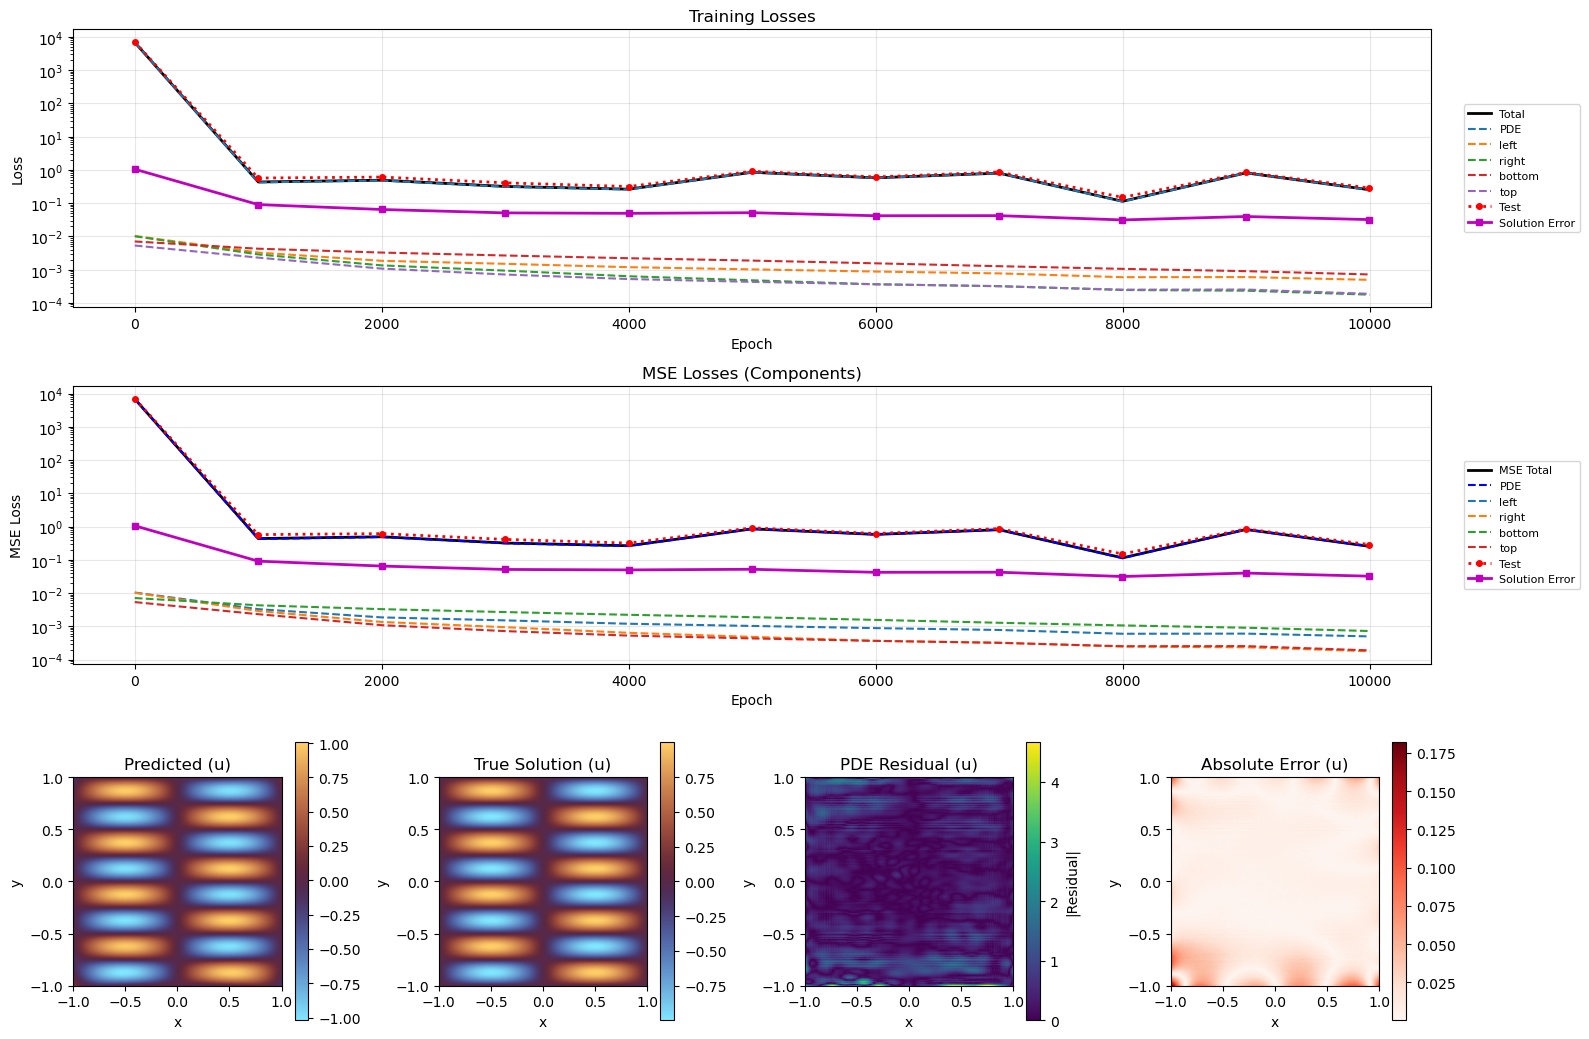

Epoch 1000/10000 | Loss: 4.35e-01 | MSE Loss: 4.35e-01 | PDE: 4.22e-01 | BCs: [left: 3.28e-03, right: 2.88e-03, bottom: 4.28e-03, top: 2.31e-03] | Time: 8.3s | Test Loss: 5.71e-01 | Error: 9.09e-02
Epoch 2000/10000 | Loss: 4.92e-01 | MSE Loss: 4.92e-01 | PDE: 4.84e-01 | BCs: [left: 1.85e-03, right: 1.35e-03, bottom: 3.28e-03, top: 1.08e-03] | Time: 11.0s | Test Loss: 6.12e-01 | Error: 6.47e-02
Epoch 3000/10000 | Loss: 3.19e-01 | MSE Loss: 3.19e-01 | PDE: 3.13e-01 | BCs: [left: 1.50e-03, right: 9.38e-04, bottom: 2.67e-03, top: 7.16e-04] | Time: 13.5s | Test Loss: 4.10e-01 | Error: 5.12e-02
Epoch 4000/10000 | Loss: 2.64e-01 | MSE Loss: 2.64e-01 | PDE: 2.60e-01 | BCs: [left: 1.19e-03, right: 6.35e-04, bottom: 2.21e-03, top: 5.24e-04] | Time: 16.0s | Test Loss: 3.17e-01 | Error: 4.96e-02
Epoch 5000/10000 | Loss: 8.51e-01 | MSE Loss: 8.51e-01 | PDE: 8.47e-01 | BCs: [left: 1.02e-03, right: 4.80e-04, bottom: 1.88e-03, top: 4.31e-04] | Time: 18.4s | Test Loss: 9.12e-01 | Error: 5.18e-02
Epoch 

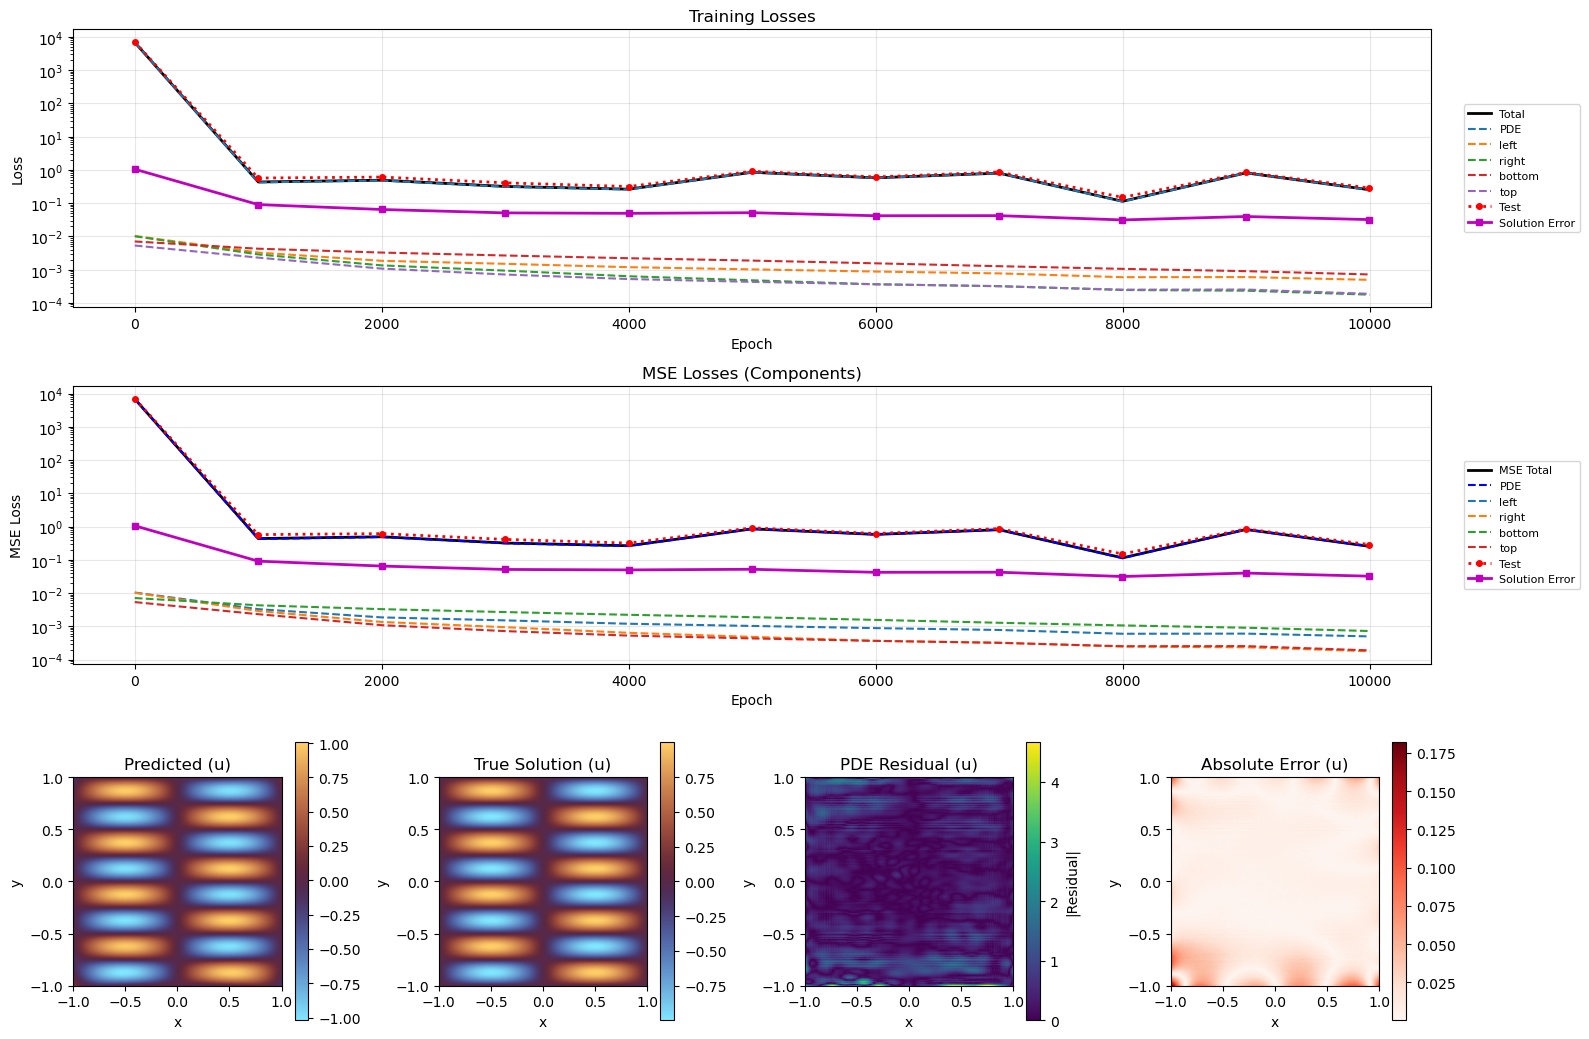

In [8]:
trainer = pinns.Trainer(
    problem,
    network,
)

trainer.compile(
    train_samples = {
        "pde": 5000,
        "left": 100,
        "right": 100,
        "bottom": 100,
        "top": 100,
    },
    test_samples = {
        "pde": 5000,
        "left": 0,
        "right": 0,
        "bottom": 0,
        "top": 0,
    },
    weights={
        "pde": 1.0,
        "left": 1.0,
        "right": 1.0,
        "bottom": 1.0,
        "top": 1.0,
    },
    optimizer="adam",
    learning_rate=1e-3,
    epochs=10000,
    print_each=1000,
    show_plots=True,
)

trainer.train()

# Solve with ALPINN (Augmented Lagrangian PINN)

## Network Architecture

For ALPINN, we use the same FBPINN architecture but with the Augmented Lagrangian training method.

In [9]:
# No output normalization (paper doesn't use it)
network = pinns.FNN([2, 256, 256, 1], activation="tanh", normalize_input=True, unnormalize_output=False)

## Training Configuration

ALPINN uses the Augmented Lagrangian method to enforce constraints more effectively:
- **betas**: Penalty parameters for each constraint
- **lambda_lr**: Learning rate for Lagrange multiplier updates
- **inner_epochs**: Number of primal optimization steps before each λ update

Starting ALTrainer (JAX) for 10000 epochs...
Weights (penalty parameters): {'pde': 1.0, 'left': 500.0, 'right': 500.0, 'bottom': 500.0, 'top': 500.0}
λ optimizer: adam, lr: 1
Epoch 0/10000 | AL Loss: 7.90e+03 | MSE Loss: 7.22e+03 | PDE: 7.22e+03 | BCs: [left: 1.78e-01, right: 1.77e-01, bottom: 4.97e-01, top: 4.98e-01] | Time: 2.5s | Test: 7.13e+03 | Error: 1.24e+00


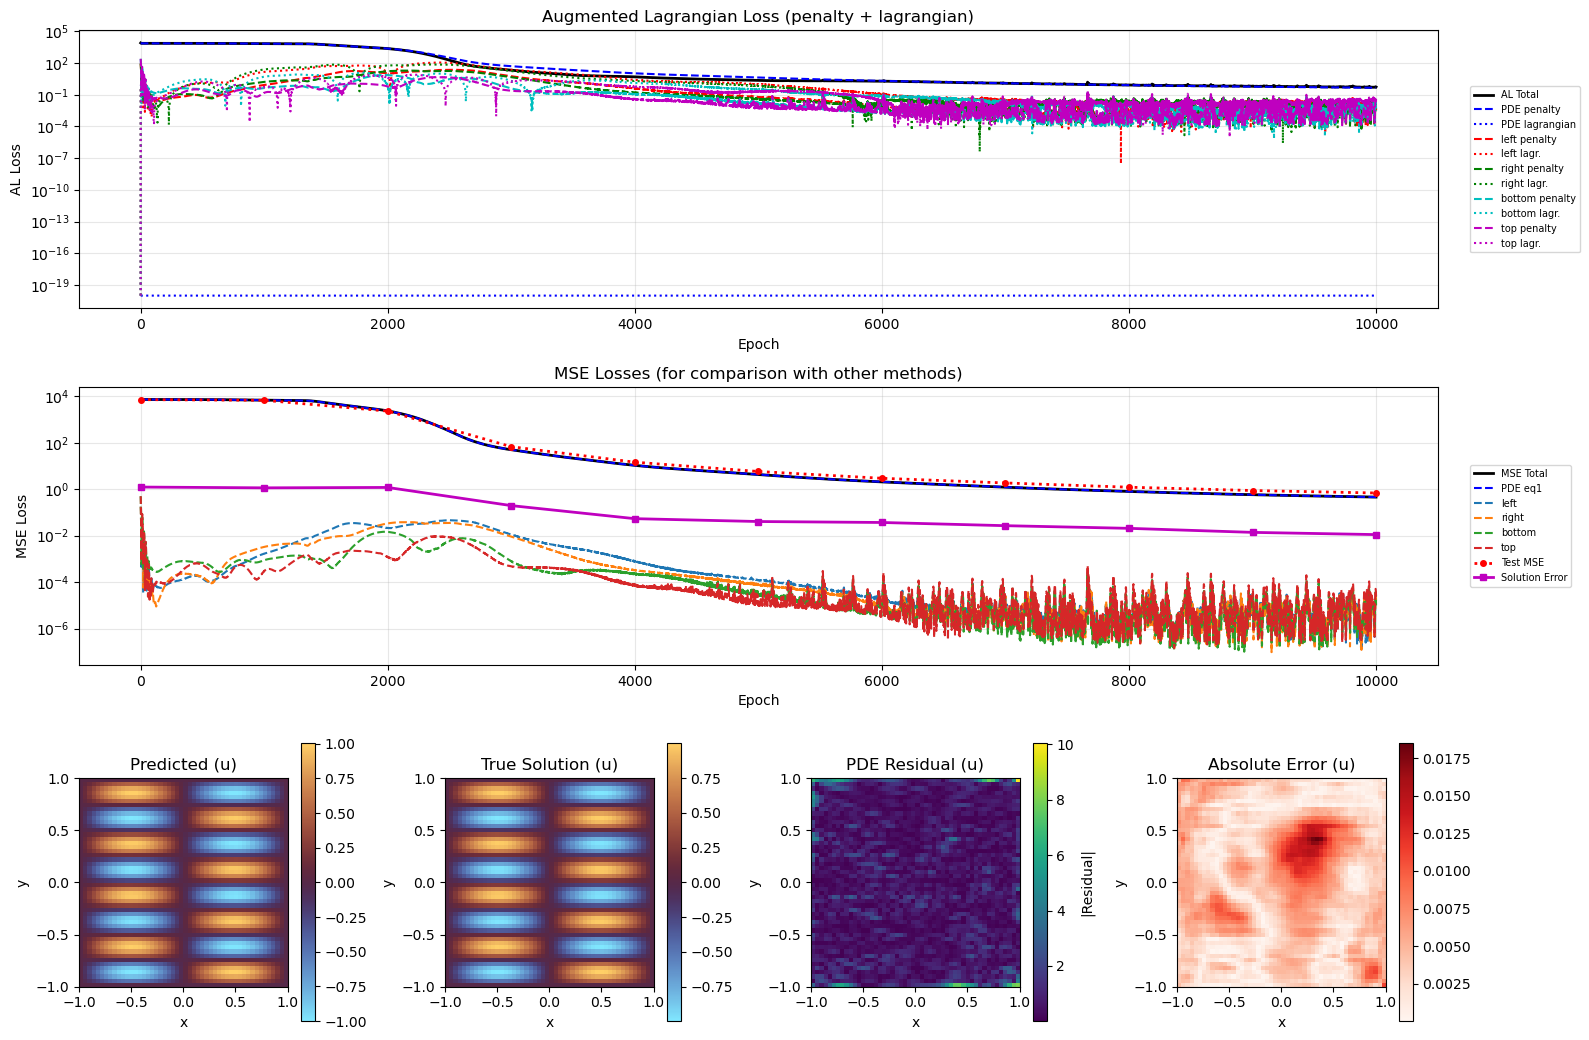

Epoch 1000/10000 | AL Loss: 6.84e+03 | MSE Loss: 6.79e+03 | PDE: 6.79e+03 | BCs: [left: 1.68e-03, right: 3.30e-03, bottom: 8.78e-04, top: 3.08e-04] | Time: 8.6s | Test: 6.69e+03 | Error: 1.14e+00
Epoch 2000/10000 | AL Loss: 2.32e+03 | MSE Loss: 2.33e+03 | PDE: 2.33e+03 | BCs: [left: 2.13e-02, right: 3.38e-02, bottom: 1.45e-02, top: 1.22e-03] | Time: 13.3s | Test: 2.29e+03 | Error: 1.19e+00
Epoch 3000/10000 | AL Loss: 2.02e+01 | MSE Loss: 4.96e+01 | PDE: 4.95e+01 | BCs: [left: 1.12e-02, right: 9.07e-03, bottom: 7.89e-04, top: 4.74e-04] | Time: 17.8s | Test: 6.73e+01 | Error: 1.97e-01
Epoch 4000/10000 | AL Loss: 4.89e+00 | MSE Loss: 1.06e+01 | PDE: 1.06e+01 | BCs: [left: 7.67e-04, right: 3.28e-04, bottom: 2.19e-04, top: 7.91e-05] | Time: 22.4s | Test: 1.45e+01 | Error: 5.39e-02
Epoch 5000/10000 | AL Loss: 2.22e+00 | MSE Loss: 4.27e+00 | PDE: 4.27e+00 | BCs: [left: 1.22e-04, right: 7.85e-05, bottom: 2.66e-05, top: 1.20e-05] | Time: 27.6s | Test: 5.78e+00 | Error: 4.07e-02
Epoch 6000/10000

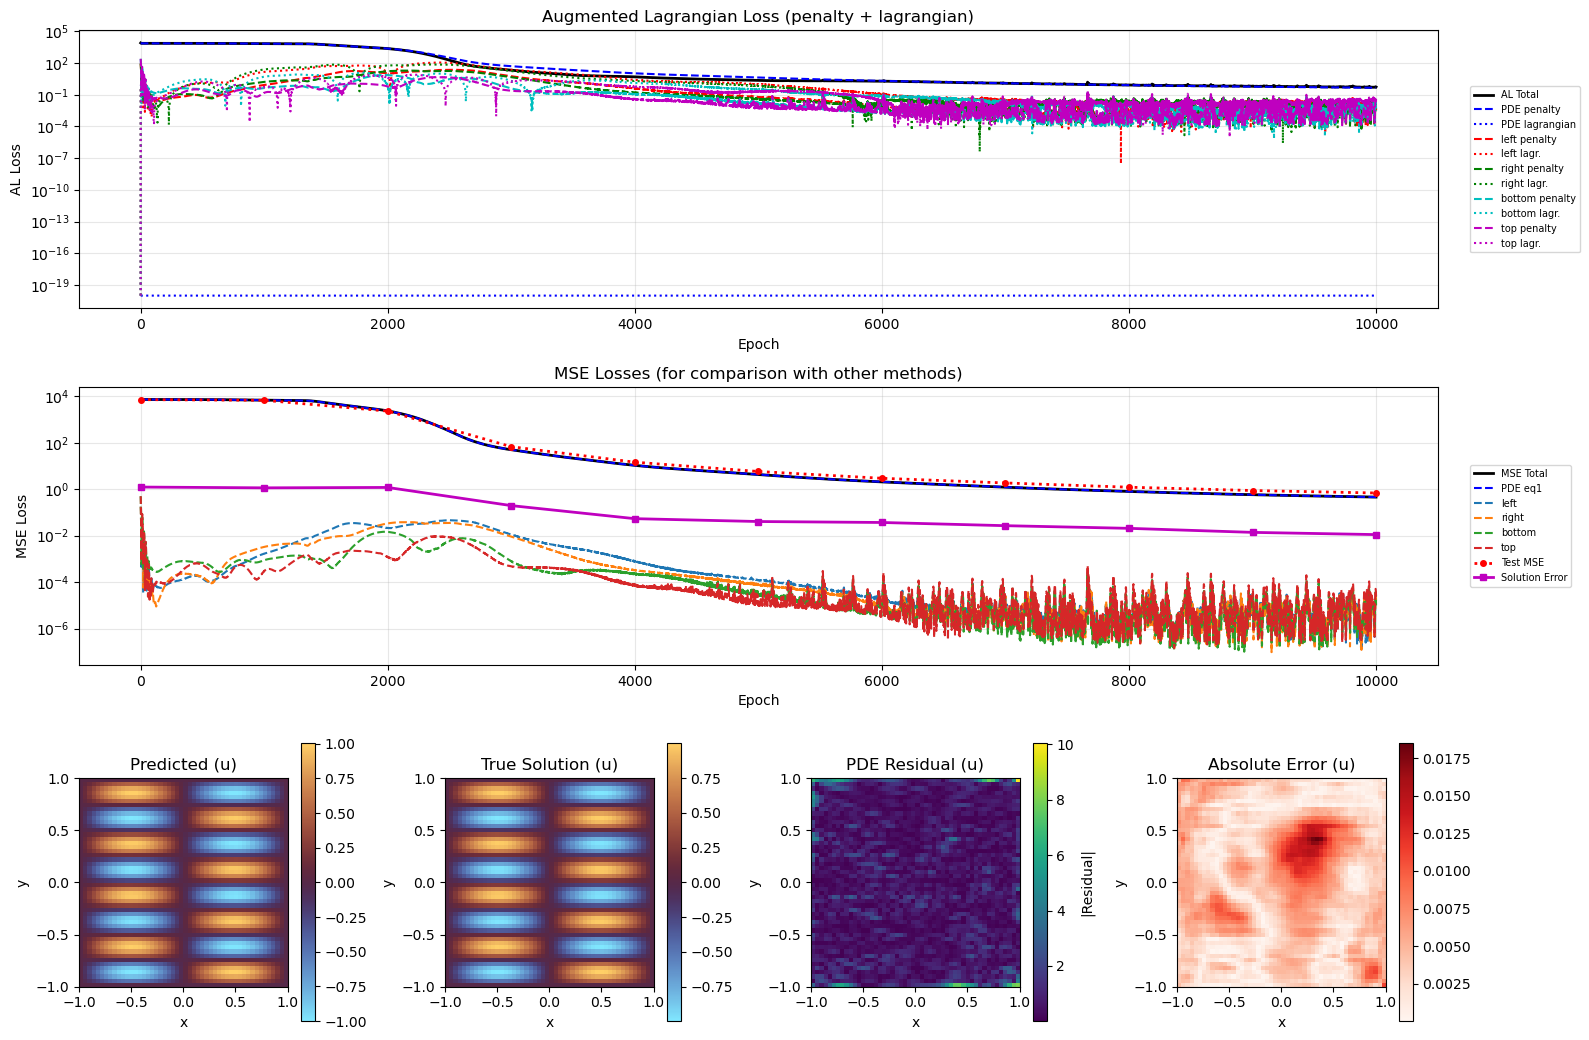

In [10]:
trainer = pinns.ALTrainer(
    problem,
    network,
)

# Match paper exactly:
# - 51x51=2601 interior points
# - ~200 boundary points total (51 per edge, but corners counted once)
# - β=500 for boundary (divide by 4 since we have 4 separate edges)
# - lr=1e-3, λ_lr=1
# - λ optimizer = Adam (default, matching paper)
trainer.compile(
    train_samples = {
        "pde": 2601,  # Match paper: 51x51 grid
        "left": 51,
        "right": 51,
        "bottom": 51,
        "top": 51,
    },
    test_samples = {
        "pde": 1000,
        "left": 0,
        "right": 0,
        "bottom": 0,
        "top": 0,
    },
    weights={
        "pde": 1.0,
        "left": 500.0,
        "right": 500.0,
        "bottom": 500.0,
        "top": 500.0,
    },
    optimizer="adam",
    learning_rate=1e-4,  # Paper uses 1e-3
    lagrange_constraints=['left', 'right', 'bottom', 'top'],  # λ only on boundaries (paper formulation)
    lagrange_optimizer='adam',  # Adam for λ updates (matching paper)
    lagrange_lr=1,
    epochs=10000,
    print_each=1000,
    plot_n_points=50,
    show_plots=True,
)

trainer.train()